# Task 2 — Scenario Selection and Harmonisation

**Source:** NGFS Phase 5 v5.1 (March 2026) — IAM_data.xlsx. https://data.ece.iiasa.ac.at/ngfs/#/downloads  
**Citation:** Richters et al. (2026). NGFS Climate Scenarios Data Set (5.1). Zenodo. https://doi.org/10.5281/zenodo.17901363  
**Model:** REMIND-MAgPIE 3.3-4.8 (standard variant, no integrated physical damages). Inter-model robustness check : GCAM 6.0 NGFS, region EU-15, same 3 scenarios. Carbon price trajectories compared.
**Region:** `REMIND-MAgPIE 3.3-4.8|EU 28` — used as proxy for EU27. The UK is included in this regional aggregate but its weight is small (~10% of EU28 thermal capacity) and its carbon/electricity price dynamics are close to continental levels. Documented as a limitation.

**Three scenarios retained:**

| Scenario | Type | Logic |
|---|---|---|
| Net Zero 2050 | Orderly | Strong progressive carbon price from 2020. Maximum stranding spread over time. |
| Delayed transition | Disorderly | Carbon price flat until ~2030, then sharp shock. Stranding concentrated post-2030. |
| Current Policies | Insufficient | Carbon price quasi-flat throughout. Minimal transition stranding. |

**Variables extracted:**

| NGFS variable | Role in model | Unit (raw) |
|---|---|---|
| `Price\|Carbon` | $C^{CO_2}_{p,t}$ driver | US\$2010/tCO2 |
| `Price\|Secondary Energy\|Electricity` | $P_t$ in $\pi_{p,t}$ | US\$2010/GJ |
| `Price\|Primary Energy\|Coal` | $C^{fuel}$ coal | US\$2010/GJ |
| `Price\|Primary Energy\|Gas` | $C^{fuel}$ gas | US\$2010/GJ |
| `Price\|Primary Energy\|Oil` | $C^{fuel}$ oil | US\$2010/GJ |
| `Secondary Energy\|Electricity\|Coal` | Capacity factor calibration (coal) | EJ/yr |
| `Secondary Energy\|Electricity\|Gas` | Capacity factor calibration (gas) | EJ/yr |
| `Secondary Energy\|Electricity\|Oil` | Capacity factor calibration (oil) | EJ/yr |
| `Emissions\|CO2\|Energy\|Supply\|Electricity` | Model validation | MtCO2/yr |

**Unit conversion:**  
Price variables in US\$2010/GJ are converted to EUR2024/MWh:  
$$\text{EUR2024/MWh} = \text{US\$2010/GJ} \times \underbrace{3.6}_{\text{GJ}\to\text{MWh}} \times \underbrace{1.33}_{\text{USD2010}\to\text{EUR2024}}$$
The factor 1.33 combines USD CPI inflation 2010→2024 (×1.438, BLS CPI-U annual averages: 218.056 → 313.515) and 2024 average USD/EUR exchange rate (×0.924, ECB: 1 EUR = 1.0822 USD). Sensitised in Task 7. 
`Price|Carbon` (US\$2010/tCO2): multiply by 1.33 only.  
Energy variables (EJ/yr): converted to MWh/yr (x277.78x10^6). Emissions (MtCO2/yr): converted to tCO2/yr (x10^6).

**Temporal harmonisation:**  
NGFS data is at 5-year intervals (2020, 2025, ..., 2050). Linear interpolation to annual steps (2020-2050). Standard approach in the stranding literature — avoids false precision given IAM projection uncertainty.

Note — modified by Task 3:
Fuel price variables (Price|Primary Energy|*) are converted from EUR2024/MWh_th to EUR2024/MWh_elec (divided by fleet-average η per fuel) during Task 3 execution, and saved into ngfs_scenarios_elec.csv.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)

### 1. Load and filter raw NGFS data

We filter immediately on model, region, scenarios and variables of interest to keep only the 27 rows we need from the full ~300k-row dataset.

In [2]:
MODEL    = 'REMIND-MAgPIE 3.3-4.8'
REGION   = 'REMIND-MAgPIE 3.3-4.8|EU 28'
SCENARIOS = ['Net Zero 2050', 'Delayed transition', 'Current Policies']

VARS_PRICE = [
    'Price|Carbon',
    'Price|Secondary Energy|Electricity',
    'Price|Primary Energy|Coal',
    'Price|Primary Energy|Gas',
    'Price|Primary Energy|Oil',
]
VARS_ENERGY = [
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Oil',
]
VARS_EMISSIONS = ['Emissions|CO2|Energy|Supply|Electricity']
VARS_ALL = VARS_PRICE + VARS_ENERGY + VARS_EMISSIONS

YEAR_COLS = [str(y) for y in range(2020, 2105, 5)]

df_raw = pd.read_excel('../../data/raw/IAM_data.xlsx')

df = df_raw[
    (df_raw['Model'] == MODEL) &
    (df_raw['Region'] == REGION) &
    (df_raw['Scenario'].isin(SCENARIOS)) &
    (df_raw['Variable'].isin(VARS_ALL))
].copy()

print(f"Rows retained : {len(df)} (expected: {len(SCENARIOS) * len(VARS_ALL)})")
print()
display(df[['Model','Scenario','Variable','Unit']].sort_values(['Scenario','Variable']).reset_index(drop=True))

Rows retained : 27 (expected: 27)



,Model,Scenario,Variable,Unit
0,REMIND-MAgPIE 3.3-4.8,Current Policies,Emissions|CO2|Energy|Supply|Electricity,Mt CO2/yr
1,REMIND-MAgPIE 3.3-4.8,Current Policies,Price|Carbon,US$2010/t CO2
2,REMIND-MAgPIE 3.3-4.8,Current Policies,Price|Primary Energy|Coal,US$2010/GJ
3,REMIND-MAgPIE 3.3-4.8,Current Policies,Price|Primary Energy|Gas,US$2010/GJ
4,REMIND-MAgPIE 3.3-4.8,Current Policies,Price|Primary Energy|Oil,US$2010/GJ
5,REMIND-MAgPIE 3.3-4.8,Current Policies,Price|Secondary Energy|Electricity,US$2010/GJ
6,REMIND-MAgPIE 3.3-4.8,Current Policies,Secondary Energy|Electricity|Coal,EJ/yr
7,REMIND-MAgPIE 3.3-4.8,Current Policies,Secondary Energy|Electricity|Gas,EJ/yr
8,REMIND-MAgPIE 3.3-4.8,Current Policies,Secondary Energy|Electricity|Oil,EJ/yr
9,REMIND-MAgPIE 3.3-4.8,Delayed transition,Emissions|CO2|Energy|Supply|Electricity,Mt CO2/yr


### 2. Reshape to long format and interpolate to annual grid

Data is pivoted from wide (one column per year) to long (one row per year), then reindexed on 2020-2050 and linearly interpolated to fill the 5-year gaps.

In [3]:
year_cols_2050 = [str(y) for y in range(2020, 2055, 5)]

df_long = df.melt(
    id_vars=['Model', 'Scenario', 'Region', 'Variable', 'Unit'],
    value_vars=year_cols_2050,
    var_name='year',
    value_name='value'
)
df_long['year'] = df_long['year'].astype(int)

annual_years = pd.Index(range(2020, 2051), name='year')
records = []

for (scenario, variable), grp in df_long.groupby(['Scenario', 'Variable']):
    unit = grp['Unit'].iloc[0]
    s = grp.set_index('year')['value'].reindex(annual_years)
    s = s.interpolate(method='linear')
    for yr, val in s.items():
        records.append({
            'scenario': scenario,
            'variable': variable,
            'unit_raw': unit,
            'year': yr,
            'value_raw': val
        })

df_annual = pd.DataFrame(records)
print(f"Annual dataset shape: {df_annual.shape}")
print(f"Years: {df_annual['year'].min()} - {df_annual['year'].max()}")
print(f"NaN values: {df_annual['value_raw'].isna().sum()}")

Annual dataset shape: (837, 5)
Years: 2020 - 2050
NaN values: 0


### 3. Unit conversion

Conversion rules applied:
- `Price|Carbon` (US$2010/tCO2): x1.33 -> EUR2024/tCO2
- Price variables (US$2010/GJ): x3.6x1.33 = x4.788 -> EUR2024/MWh
- Energy variables (EJ/yr): x277.78x10^6 -> MWh/yr
- Emissions (MtCO2/yr): x10^6 -> tCO2/yr

In [4]:
FX_INFLATION = 1.33       # USD2010 -> EUR2024 (CPI 1.438 x FX 0.924)
GJ_TO_MWH   = 3.6         # 1 MWh = 3.6 GJ
EJ_TO_MWH   = 277.78 * 1e6  # 1 EJ = 277.78 TWh

def convert_value(row):
    if row['variable'] == 'Price|Carbon':
        return row['value_raw'] * FX_INFLATION, 'EUR2024/tCO2'
    elif row['unit_raw'] == 'US$2010/GJ':
        return row['value_raw'] * GJ_TO_MWH * FX_INFLATION, 'EUR2024/MWh'
    elif 'Secondary Energy|Electricity' in row['variable']:
        return row['value_raw'] * EJ_TO_MWH, 'MWh/yr'
    elif 'Emissions|CO2|Energy|Supply|Electricity' in row['variable']:
        return row['value_raw'] * 1e6, 'tCO2/yr'
    else:
        return row['value_raw'], row['unit_raw']

df_annual[['value', 'unit']] = df_annual.apply(
    convert_value, axis=1, result_type='expand'
)

check = df_annual[
    df_annual['year'].isin([2020, 2030, 2040, 2050])
].pivot_table(
    index=['variable','unit'],
    columns=['scenario','year'],
    values='value'
).round(1)

print("Key values after conversion (selected years):")
display(check)

Key values after conversion (selected years):


scenario                                             Current Policies  \
year                                                             2020   
variable                                unit                            
Emissions|CO2|Energy|Supply|Electricity tCO2/yr        762,687,906.10   
Price|Carbon                            EUR2024/tCO2            37.20   
Price|Primary Energy|Coal               EUR2024/MWh             10.90   
Price|Primary Energy|Gas                EUR2024/MWh             21.50   
Price|Primary Energy|Oil                EUR2024/MWh             56.30   
Price|Secondary Energy|Electricity      EUR2024/MWh            118.40   
Secondary Energy|Electricity|Coal       MWh/yr         511,553,231.30   
Secondary Energy|Electricity|Gas        MWh/yr         828,608,378.80   
Secondary Energy|Electricity|Oil        MWh/yr          45,255,056.50   

scenario                                                             \
year                                                           2030   
variable                                unit                          
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      244,014,522.80   
Price|Carbon                            EUR2024/tCO2          37.20   
Price|Primary Energy|Coal               EUR2024/MWh           11.20   
Price|Primary Energy|Gas                EUR2024/MWh           24.20   
Price|Primary Energy|Oil                EUR2024/MWh           70.00   
Price|Secondary Energy|Electricity      EUR2024/MWh           95.70   
Secondary Energy|Electricity|Coal       MWh/yr        87,245,670.20   
Secondary Energy|Electricity|Gas        MWh/yr       492,590,329.60   
Secondary Energy|Electricity|Oil        MWh/yr        10,070,441.70   

scenario                                                            \
year                                                          2040   
variable                                unit                         
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      23,631,340.60   
Price|Carbon                            EUR2024/tCO2         37.20   
Price|Primary Energy|Coal               EUR2024/MWh          12.00   
Price|Primary Energy|Gas                EUR2024/MWh          29.30   
Price|Primary Energy|Oil                EUR2024/MWh          79.10   
Price|Secondary Energy|Electricity      EUR2024/MWh          75.20   
Secondary Energy|Electricity|Coal       MWh/yr        4,886,289.10   
Secondary Energy|Electricity|Gas        MWh/yr       38,660,920.40   
Secondary Energy|Electricity|Oil        MWh/yr              333.30   

scenario                                                            \
year                                                          2050   
variable                                unit                         
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      21,025,393.20   
Price|Carbon                            EUR2024/tCO2         37.20   
Price|Primary Energy|Coal               EUR2024/MWh          13.70   
Price|Primary Energy|Gas                EUR2024/MWh          33.60   
Price|Primary Energy|Oil                EUR2024/MWh          95.00   
Price|Secondary Energy|Electricity      EUR2024/MWh          66.40   
Secondary Energy|Electricity|Coal       MWh/yr           83,389.60   
Secondary Energy|Electricity|Gas        MWh/yr       41,832,362.40   
Secondary Energy|Electricity|Oil        MWh/yr              500.00   

scenario                                             Delayed transition  \
year                                                               2020   
variable                                unit                              
Emissions|CO2|Energy|Supply|Electricity tCO2/yr          762,687,906.10   
Price|Carbon                            EUR2024/tCO2              37.20   
Price|Primary Energy|Coal               EUR2024/MWh               10.90   
Price|Primary Energy|Gas                EUR2024/MWh               21.50   
Price|Primary Energy|Oil                EUR2024/MWh            

### 4. Exploration — distributions and scenario comparison

Stats per variable and scenario to validate the conversion and understand the data range before plotting.

In [5]:
stats = df_annual.groupby(['variable', 'unit', 'scenario'])['value'].agg(
    ['min', 'mean', 'max']
).round(1)
display(stats)

min  \
variable                                unit         scenario                            
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      Current Policies    21,025,393.20   
                                                     Delayed transition -12,810,004.60   
                                                     Net Zero 2050      -44,265,325.10   
Price|Carbon                            EUR2024/tCO2 Current Policies            37.20   
                                                     Delayed transition          37.20   
                                                     Net Zero 2050               37.20   
Price|Primary Energy|Coal               EUR2024/MWh  Current Policies            10.90   
                                                     Delayed transition           7.60   
                                                     Net Zero 2050                6.50   
Price|Primary Energy|Gas                EUR2024/MWh  Current Policies            21.50   
                                                     Delayed transition          21.50   
                                                     Net Zero 2050               21.50   
Price|Primary Energy|Oil                EUR2024/MWh  Current Policies            56.30   
                                                     Delayed transition          56.30   
                                                     Net Zero 2050               56.30   
Price|Secondary Energy|Electricity      EUR2024/MWh  Current Policies            65.70   
                                                     Delayed transition          62.40   
                                                     Net Zero 2050               58.40   
Secondary Energy|Electricity|Coal       MWh/yr       Current Policies        83,389.60   
                                                     Delayed transition      23,694.60   
                                                     Net Zero 2050           14,416.80   
Secondary Energy|Electricity|Gas        MWh/yr       Current Policies    38,660,920.40   
                                                     Delayed transition  10,349,610.60   
                                                     Net Zero 2050          206,946.10   
Secondary Energy|Electricity|Oil        MWh/yr       Current Policies           222.20   
                                                     Delayed transition         222.20   
                                                     Net Zero 2050              222.20   

                                                                                  mean  \
variable                                unit         scenario                            
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      Current Policies   219,304,698.40   
                                                     Delayed transition 207,767,773.60   
                                                     Net Zero 2050      140,710,858.50   
Price|Carbon                            EUR2024/tCO2 Current Policies            37.20   
                                                     Delayed transition         356.40   
                                                     Net Zero 2050              689.20   
Price|Primary Energy|Coal               EUR2024/MWh  Current Policies            11.80   
                                                     Delayed transition          10.10   
                                                     Net Zero 2050                8.70   
Price|Primary Energy|Gas                EUR2024/MWh  Current Policies            27.30   
                                                     Delayed transition          25.70   
                                                     Net Zero 2050               26.80   
Price|Primary Energy|Oil                EUR2024/MWh  Current Policies            74.60   
                                                     Delayed transition          69.70   
                                

### 5. Figure 1 — Carbon price trajectories

The most important figure of Task 2. Structural difference between the three scenarios:
- Net Zero 2050: progressive and strong increase from 2020
- Delayed transition: flat until ~2030, then sharp shock — the most financially destabilising profile
- Current Policies: quasi-flat throughout

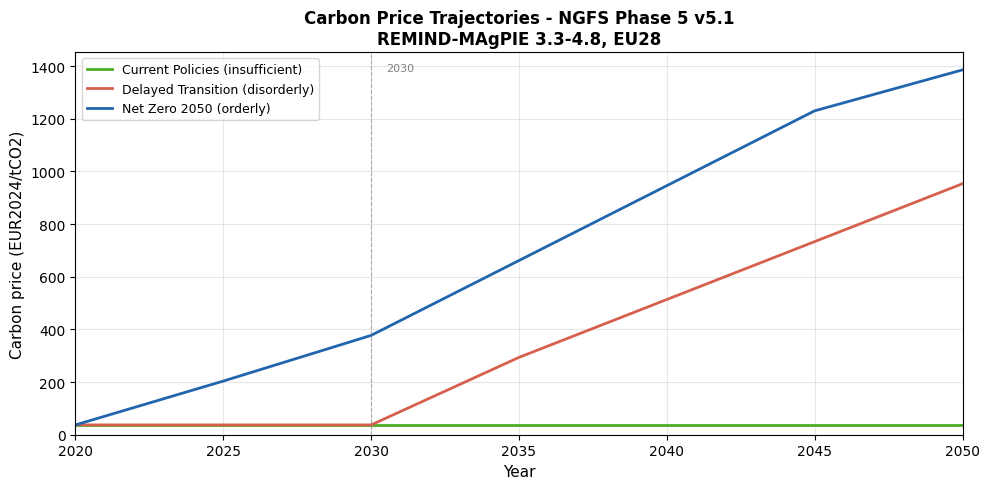

In [6]:
SCENARIO_COLORS = {
    'Net Zero 2050'    : '#2166ac',
    'Delayed transition': '#d6604d',
    'Current Policies' : '#4dac26'
}
SCENARIO_LABELS = {
    'Net Zero 2050'    : 'Net Zero 2050 (orderly)',
    'Delayed transition': 'Delayed Transition (disorderly)',
    'Current Policies' : 'Current Policies (insufficient)'
}

fig, ax = plt.subplots(figsize=(10, 5))

carbon = df_annual[df_annual['variable'] == 'Price|Carbon']
for scenario, grp in carbon.groupby('scenario'):
    grp_sorted = grp.sort_values('year')
    ax.plot(
        grp_sorted['year'], grp_sorted['value'],
        color=SCENARIO_COLORS[scenario],
        label=SCENARIO_LABELS[scenario],
        linewidth=2
    )

ax.axvline(2030, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(2030.5, ax.get_ylim()[1]*0.95, '2030', fontsize=8, color='grey')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Carbon price (EUR2024/tCO2)', fontsize=11)
ax.set_title('Carbon Price Trajectories - NGFS Phase 5 v5.1\nREMIND-MAgPIE 3.3-4.8, EU28', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(2020, 2050)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/figures/fig2_carbon_price_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Figure 2 — Electricity price trajectories

Counter-intuitive result: electricity prices decline under Net Zero 2050 in the long run. This reflects the falling cost of renewables dominating the mix by 2050, more than offsetting the carbon cost pass-through. Direct impact on plant revenues $P_t$ in $\pi_{p,t}$.

The electricity price in 2050 for scenario "Current Policies (insufficient)" is 66.45 EUR2024/MWh
The electricity price in 2050 for scenario "Delayed Transition (disorderly)" is 62.38 EUR2024/MWh
The electricity price in 2050 for scenario "Net Zero 2050 (orderly)" is 58.40 EUR2024/MWh


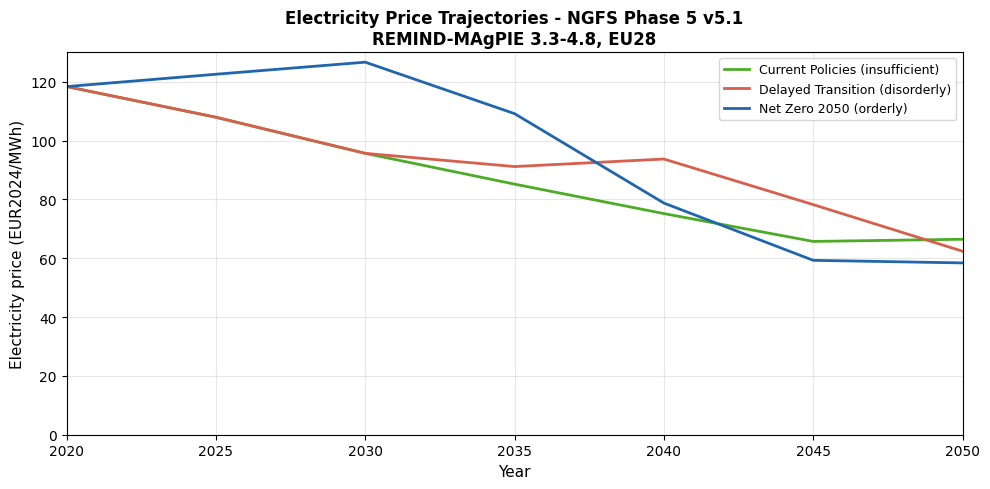

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

elec = df_annual[df_annual['variable'] == 'Price|Secondary Energy|Electricity']
for scenario, grp in elec.groupby('scenario'):
    grp_sorted = grp.sort_values('year')
    ax.plot(
        grp_sorted['year'], grp_sorted['value'],
        color=SCENARIO_COLORS[scenario],
        label=SCENARIO_LABELS[scenario],
        linewidth=2
    )
    print(f"The electricity price in 2050 for scenario \"{SCENARIO_LABELS[scenario]}\" is {grp_sorted[grp_sorted['year'] == 2050]['value'].values[0]:.2f} EUR2024/MWh")

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Electricity price (EUR2024/MWh)', fontsize=11)
ax.set_title('Electricity Price Trajectories - NGFS Phase 5 v5.1\nREMIND-MAgPIE 3.3-4.8, EU28', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(2020, 2050)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/figures/fig3_electricity_price_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Figure 3 — Fuel price trajectories (coal, gas, oil)

Fuel prices vary across scenarios. Under Net Zero 2050, coal demand collapses globally, pushing its price down. Gas and oil follow similar but less pronounced trends. These drive $C^{fuel}_{p,t}$ in $\pi_{p,t}$.

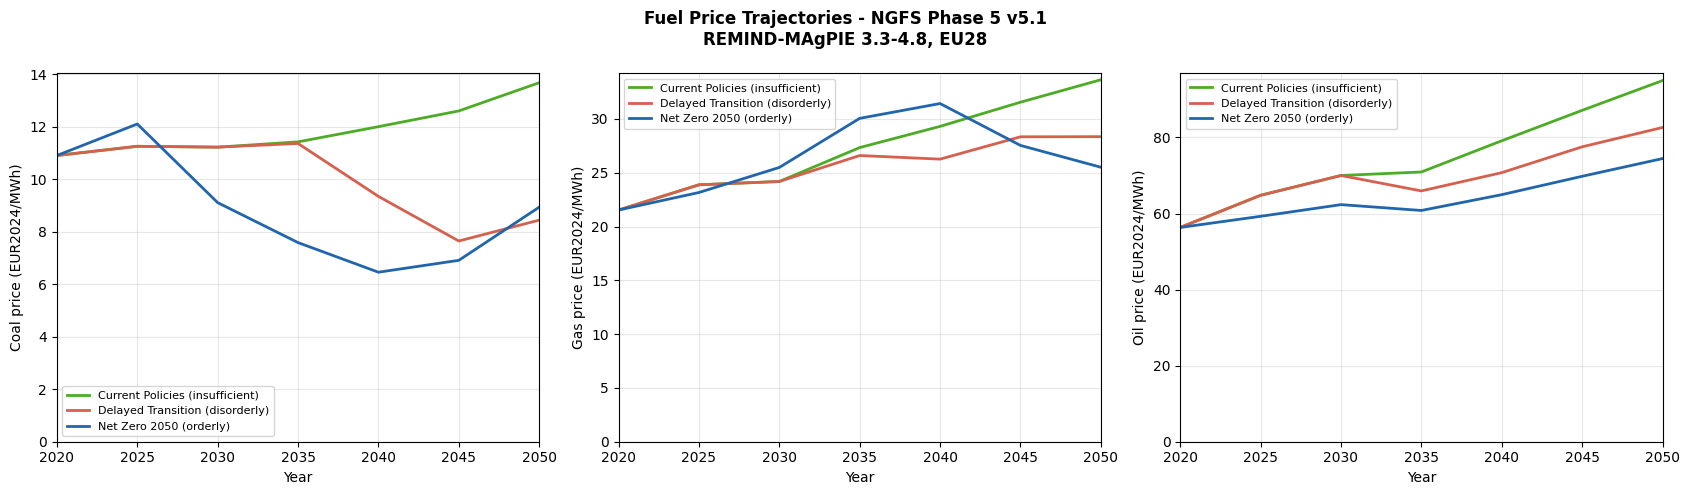

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, var, title in zip(
    axes,
    ['Price|Primary Energy|Coal', 'Price|Primary Energy|Gas', 'Price|Primary Energy|Oil'],
    ['Coal price (EUR2024/MWh)', 'Gas price (EUR2024/MWh)', 'Oil price (EUR2024/MWh)']
):
    sub = df_annual[df_annual['variable'] == var]
    for scenario, grp in sub.groupby('scenario'):
        grp_sorted = grp.sort_values('year')
        ax.plot(
            grp_sorted['year'], grp_sorted['value'],
            color=SCENARIO_COLORS[scenario],
            label=SCENARIO_LABELS[scenario],
            linewidth=2
        )
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_xlim(2020, 2050)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Fuel Price Trajectories - NGFS Phase 5 v5.1\nREMIND-MAgPIE 3.3-4.8, EU28',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig4_fuel_price_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Figure 4 — Electricity generation mix (coal, gas, oil)

These trajectories are used in Task 3 to derive time-varying capacity factors. The near-complete disappearance of coal generation under Net Zero 2050 by 2040 drives coal capacity factors to near zero, mechanically accelerating economic stranding.

Note: Current Policies and Delayed Transition overlap on coal generation (identical trajectories until ~2030, as Delayed Transition maintains fossil policies until that point by definition). Delayed Transition is plotted dashed to distinguish the two overlapping curves.

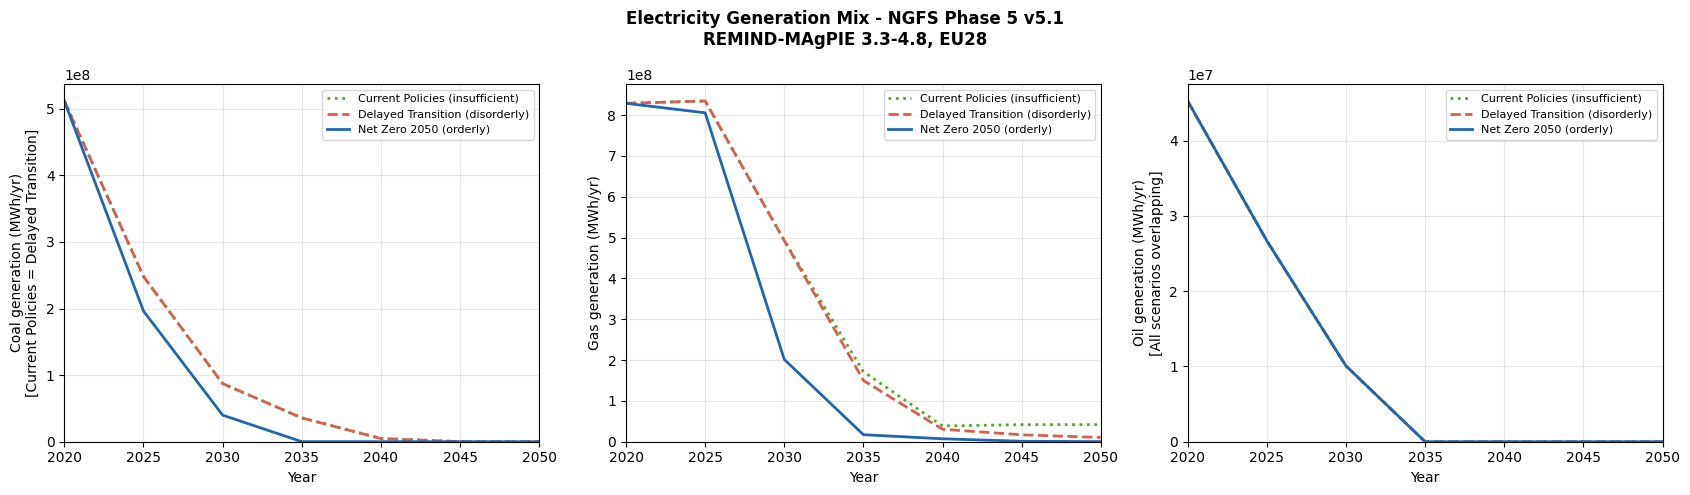

In [9]:
# Delayed Transition overlaps with Current Policies on coal — dashed line to distinguish
SCENARIO_LINESTYLE = {
    'Net Zero 2050'    : '-',
    'Delayed transition': '--',
    'Current Policies' : ':',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, var, title in zip(
    axes,
    ['Secondary Energy|Electricity|Coal',
     'Secondary Energy|Electricity|Gas',
     'Secondary Energy|Electricity|Oil'],
    ['Coal generation (MWh/yr)\n[Current Policies = Delayed Transition]',
     'Gas generation (MWh/yr)',
     'Oil generation (MWh/yr)\n[All scenarios overlapping]']
):
    sub = df_annual[df_annual['variable'] == var]
    for scenario, grp in sub.groupby('scenario'):
        grp_sorted = grp.sort_values('year')
        ax.plot(
            grp_sorted['year'], grp_sorted['value'],
            color=SCENARIO_COLORS[scenario],
            linestyle=SCENARIO_LINESTYLE[scenario],
            label=SCENARIO_LABELS[scenario],
            linewidth=2
        )
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_xlim(2020, 2050)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Electricity Generation Mix - NGFS Phase 5 v5.1\nREMIND-MAgPIE 3.3-4.8, EU28',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig5_generation_mix_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Save output

Final dataset: one row per (scenario, variable, year), with converted values and units.

In [10]:
df_out = df_annual[['scenario', 'variable', 'unit', 'year', 'value']].copy()
df_out = df_out.sort_values(['scenario', 'variable', 'year']).reset_index(drop=True)

df_out.to_csv('../../data/processed/ngfs_scenarios.csv', index=False)

print(f"Saved: data/processed/ngfs_scenarios.csv")
print(f"Shape : {df_out.shape[0]:,} rows x {df_out.shape[1]} columns")
print(f"       = {df_out['scenario'].nunique()} scenarios"
      f" x {df_out['variable'].nunique()} variables"
      f" x {df_out['year'].nunique()} years")
print()

display(
    df_out[
        df_out['year'].isin([2020, 2030, 2040, 2050])
    ].pivot_table(
        index=['variable', 'unit'],
        columns=['scenario', 'year'],
        values='value'
    ).round(1)
)

Saved: data/processed/ngfs_scenarios.csv
Shape : 837 rows x 5 columns
       = 3 scenarios x 9 variables x 31 years



scenario                                             Current Policies  \
year                                                             2020   
variable                                unit                            
Emissions|CO2|Energy|Supply|Electricity tCO2/yr        762,687,906.10   
Price|Carbon                            EUR2024/tCO2            37.20   
Price|Primary Energy|Coal               EUR2024/MWh             10.90   
Price|Primary Energy|Gas                EUR2024/MWh             21.50   
Price|Primary Energy|Oil                EUR2024/MWh             56.30   
Price|Secondary Energy|Electricity      EUR2024/MWh            118.40   
Secondary Energy|Electricity|Coal       MWh/yr         511,553,231.30   
Secondary Energy|Electricity|Gas        MWh/yr         828,608,378.80   
Secondary Energy|Electricity|Oil        MWh/yr          45,255,056.50   

scenario                                                             \
year                                                           2030   
variable                                unit                          
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      244,014,522.80   
Price|Carbon                            EUR2024/tCO2          37.20   
Price|Primary Energy|Coal               EUR2024/MWh           11.20   
Price|Primary Energy|Gas                EUR2024/MWh           24.20   
Price|Primary Energy|Oil                EUR2024/MWh           70.00   
Price|Secondary Energy|Electricity      EUR2024/MWh           95.70   
Secondary Energy|Electricity|Coal       MWh/yr        87,245,670.20   
Secondary Energy|Electricity|Gas        MWh/yr       492,590,329.60   
Secondary Energy|Electricity|Oil        MWh/yr        10,070,441.70   

scenario                                                            \
year                                                          2040   
variable                                unit                         
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      23,631,340.60   
Price|Carbon                            EUR2024/tCO2         37.20   
Price|Primary Energy|Coal               EUR2024/MWh          12.00   
Price|Primary Energy|Gas                EUR2024/MWh          29.30   
Price|Primary Energy|Oil                EUR2024/MWh          79.10   
Price|Secondary Energy|Electricity      EUR2024/MWh          75.20   
Secondary Energy|Electricity|Coal       MWh/yr        4,886,289.10   
Secondary Energy|Electricity|Gas        MWh/yr       38,660,920.40   
Secondary Energy|Electricity|Oil        MWh/yr              333.30   

scenario                                                            \
year                                                          2050   
variable                                unit                         
Emissions|CO2|Energy|Supply|Electricity tCO2/yr      21,025,393.20   
Price|Carbon                            EUR2024/tCO2         37.20   
Price|Primary Energy|Coal               EUR2024/MWh          13.70   
Price|Primary Energy|Gas                EUR2024/MWh          33.60   
Price|Primary Energy|Oil                EUR2024/MWh          95.00   
Price|Secondary Energy|Electricity      EUR2024/MWh          66.40   
Secondary Energy|Electricity|Coal       MWh/yr           83,389.60   
Secondary Energy|Electricity|Gas        MWh/yr       41,832,362.40   
Secondary Energy|Electricity|Oil        MWh/yr              500.00   

scenario                                             Delayed transition  \
year                                                               2020   
variable                                unit                              
Emissions|CO2|Energy|Supply|Electricity tCO2/yr          762,687,906.10   
Price|Carbon                            EUR2024/tCO2              37.20   
Price|Primary Energy|Coal               EUR2024/MWh               10.90   
Price|Primary Energy|Gas                EUR2024/MWh               21.50   
Price|Primary Energy|Oil                EUR2024/MWh            

### 10. Inter-model comparison: REMIND vs GCAM (Price|Carbon only)

In [11]:
# Diagnostic GCAM — région et scénarios disponibles
gcam = df_raw[df_raw['Model'] == 'GCAM 6.0 NGFS']
print(f"GCAM rows total : {len(gcam)}")

print(f"\nScénarios GCAM disponibles :")
for s in sorted(gcam['Scenario'].unique()):
    print(f"  '{s}'")

print(f"\nRégions GCAM ayant Price|Carbon :")
gcam_carbon = gcam[gcam['Variable'] == 'Price|Carbon']
for r in sorted(gcam_carbon['Region'].unique()):
    print(f"  '{r}'")

GCAM rows total : 125162

Scénarios GCAM disponibles :
  'Below 2°C'
  'Current Policies'
  'Delayed transition'
  'Fragmented World'
  'Low demand'
  'Nationally Determined Contributions (NDCs)'
  'Net Zero 2050'

Régions GCAM ayant Price|Carbon :
  'Asia (R5)'
  'GCAM 6.0 NGFS|Africa_Eastern'
  'GCAM 6.0 NGFS|Africa_Northern'
  'GCAM 6.0 NGFS|Africa_Southern'
  'GCAM 6.0 NGFS|Africa_Western'
  'GCAM 6.0 NGFS|Argentina'
  'GCAM 6.0 NGFS|Australia_NZ'
  'GCAM 6.0 NGFS|Brazil'
  'GCAM 6.0 NGFS|Canada'
  'GCAM 6.0 NGFS|Central America and Caribbean'
  'GCAM 6.0 NGFS|Central Asia'
  'GCAM 6.0 NGFS|China'
  'GCAM 6.0 NGFS|Colombia'
  'GCAM 6.0 NGFS|EU-12'
  'GCAM 6.0 NGFS|EU-15'
  'GCAM 6.0 NGFS|Europe_Eastern'
  'GCAM 6.0 NGFS|Europe_Non_EU'
  'GCAM 6.0 NGFS|European Free Trade Association'
  'GCAM 6.0 NGFS|India'
  'GCAM 6.0 NGFS|Indonesia'
  'GCAM 6.0 NGFS|Japan'
  'GCAM 6.0 NGFS|Mexico'
  'GCAM 6.0 NGFS|Middle East'
  'GCAM 6.0 NGFS|Pakistan'
  'GCAM 6.0 NGFS|Russia'
  'GCAM 6.0 NGFS|S

In [12]:
# Vérifie si EU-15 et EU-12 ont le même prix carbone sous GCAM
gcam_check = df_raw[
    (df_raw['Model'] == 'GCAM 6.0 NGFS') &
    (df_raw['Variable'] == 'Price|Carbon') &
    (df_raw['Region'].isin(['GCAM 6.0 NGFS|EU-15', 'GCAM 6.0 NGFS|EU-12'])) &
    (df_raw['Scenario'].isin(['Net Zero 2050', 'Delayed transition', 'Current Policies']))
][['Scenario', 'Region', '2020', '2030', '2040', '2050']]

display(gcam_check.sort_values(['Scenario', 'Region']).reset_index(drop=True))

,Scenario,Region,2020,2030,2040,2050
0,Current Policies,GCAM 6.0 NGFS|EU-12,0.00,0.00,0.00,0.00
1,Current Policies,GCAM 6.0 NGFS|EU-15,0.00,0.00,0.00,0.00
2,Delayed transition,GCAM 6.0 NGFS|EU-12,0.00,0.00,189.40,929.57
3,Delayed transition,GCAM 6.0 NGFS|EU-15,0.00,0.00,189.40,929.57
4,Net Zero 2050,GCAM 6.0 NGFS|EU-12,0.00,80.92,381.30,"1,581.43"
5,Net Zero 2050,GCAM 6.0 NGFS|EU-15,0.00,80.92,381.30,"1,581.43"


GCAM rows : 3 (expected: 3)


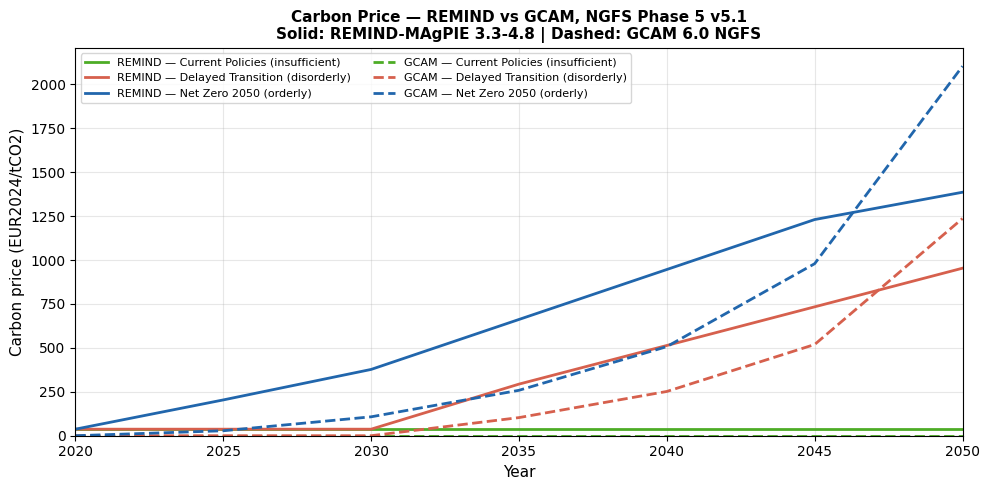


Key values (EUR2024/tCO2):
  Net Zero 2050             2030 | REMIND:   377.3 | GCAM:   107.6
  Net Zero 2050             2040 | REMIND:   946.1 | GCAM:   507.1
  Net Zero 2050             2050 | REMIND:  1386.0 | GCAM:  2103.3
  Delayed transition        2030 | REMIND:    37.2 | GCAM:     0.0
  Delayed transition        2040 | REMIND:   513.7 | GCAM:   251.9
  Delayed transition        2050 | REMIND:   953.5 | GCAM:  1236.3
  Current Policies          2030 | REMIND:    37.2 | GCAM:     0.0
  Current Policies          2040 | REMIND:    37.2 | GCAM:     0.0
  Current Policies          2050 | REMIND:    37.2 | GCAM:     0.0


In [13]:
# GCAM 6.0 NGFS uses EU-15 as EU proxy (EU-12 = EU-15 for Price|Carbon — verified above)
# Same 3 scenarios available in both models.

GCAM_MODEL  = 'GCAM 6.0 NGFS'
GCAM_REGION = 'GCAM 6.0 NGFS|EU-15'

df_gcam_raw = df_raw[
    (df_raw['Model']    == GCAM_MODEL) &
    (df_raw['Region']   == GCAM_REGION) &
    (df_raw['Scenario'].isin(SCENARIOS)) &
    (df_raw['Variable'] == 'Price|Carbon')
].copy()

print(f"GCAM rows : {len(df_gcam_raw)} (expected: {len(SCENARIOS)})")

# Reshape + interpolate (same logic as REMIND)
year_cols_2050 = [str(y) for y in range(2020, 2055, 5)]
gcam_long = df_gcam_raw.melt(
    id_vars=['Scenario','Variable','Unit'],
    value_vars=year_cols_2050,
    var_name='year', value_name='value_raw'
)
gcam_long['year'] = gcam_long['year'].astype(int)

annual_years = pd.Index(range(2020, 2051), name='year')
gcam_records = []
for scenario, grp in gcam_long.groupby('Scenario'):
    s = grp.set_index('year')['value_raw'].reindex(annual_years).interpolate('linear')
    for yr, val in s.items():
        gcam_records.append({'scenario': scenario, 'year': yr,
                             'value': val * FX_INFLATION})  # USD2010 → EUR2024
df_gcam = pd.DataFrame(gcam_records)

# Figure — annexe
fig, ax = plt.subplots(figsize=(10, 5))

MODEL_STYLE = {
    'REMIND-MAgPIE 3.3-4.8': {'lw': 2,   'ls': '-'},
    'GCAM 6.0 NGFS'         : {'lw': 2,   'ls': '--'},
}

# REMIND (already in df_annual, EUR2024/tCO2)
remind_carbon = df_annual[df_annual['variable'] == 'Price|Carbon']
for scenario, grp in remind_carbon.groupby('scenario'):
    ax.plot(grp['year'], grp['value'],
            color=SCENARIO_COLORS[scenario],
            linestyle='-', linewidth=2,
            label=f"REMIND — {SCENARIO_LABELS[scenario]}")

# GCAM
for scenario, grp in df_gcam.groupby('scenario'):
    ax.plot(grp['year'], grp['value'],
            color=SCENARIO_COLORS[scenario],
            linestyle='--', linewidth=2,
            label=f"GCAM — {SCENARIO_LABELS[scenario]}")

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Carbon price (EUR2024/tCO2)', fontsize=11)
ax.set_title('Carbon Price — REMIND vs GCAM, NGFS Phase 5 v5.1\n'
             'Solid: REMIND-MAgPIE 3.3-4.8 | Dashed: GCAM 6.0 NGFS',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(2020, 2050)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../outputs/figures/figA1_carbon_price_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Key values for report commentary
print("\nKey values (EUR2024/tCO2):")
for scenario in SCENARIOS:
    r = remind_carbon[remind_carbon['scenario']==scenario]
    g = df_gcam[df_gcam['scenario']==scenario]
    for yr in [2030, 2040, 2050]:
        rv = r[r['year']==yr]['value'].values[0]
        gv = g[g['year']==yr]['value'].values[0]
        print(f"  {scenario:25s} {yr} | REMIND: {rv:7.1f} | GCAM: {gv:7.1f}")

### 11. Baseline Validation — NGFS trajectories vs observed market prices (2020–2025)

We compare NGFS REMIND trajectories to observed market prices over 2020–2025.
This is a consistency check, not a calibration — NGFS trajectories are unchanged.

**Key finding:** NGFS is broadly coherent with 2020 pre-crisis levels. The 2021–2023
energy crisis (Ukraine war, gas supply disruption) produced market spikes far above any
NGFS scenario by construction — NGFS are structural long-term pathways, not short-term
market forecasts. 
**Note on electricity**: the NGFS electricity price includes full system costs (transmission, distribution, capacity payments), while observed Ember prices are wholesale day-ahead spot prices only — this structural difference can explains the gap at 2020 independently of the energy crisis.

**Sources:**
- Carbon: Dolphin & Xiahou (2022) *Scientific Data* 9:573 — World Carbon Pricing Database
- Electricity: Ember (2026) European Wholesale Electricity Price Data, CC-BY-4.0, ENTSO-E
- Gas / Coal: World Bank Commodity Price Data (Pink Sheet), March 2026

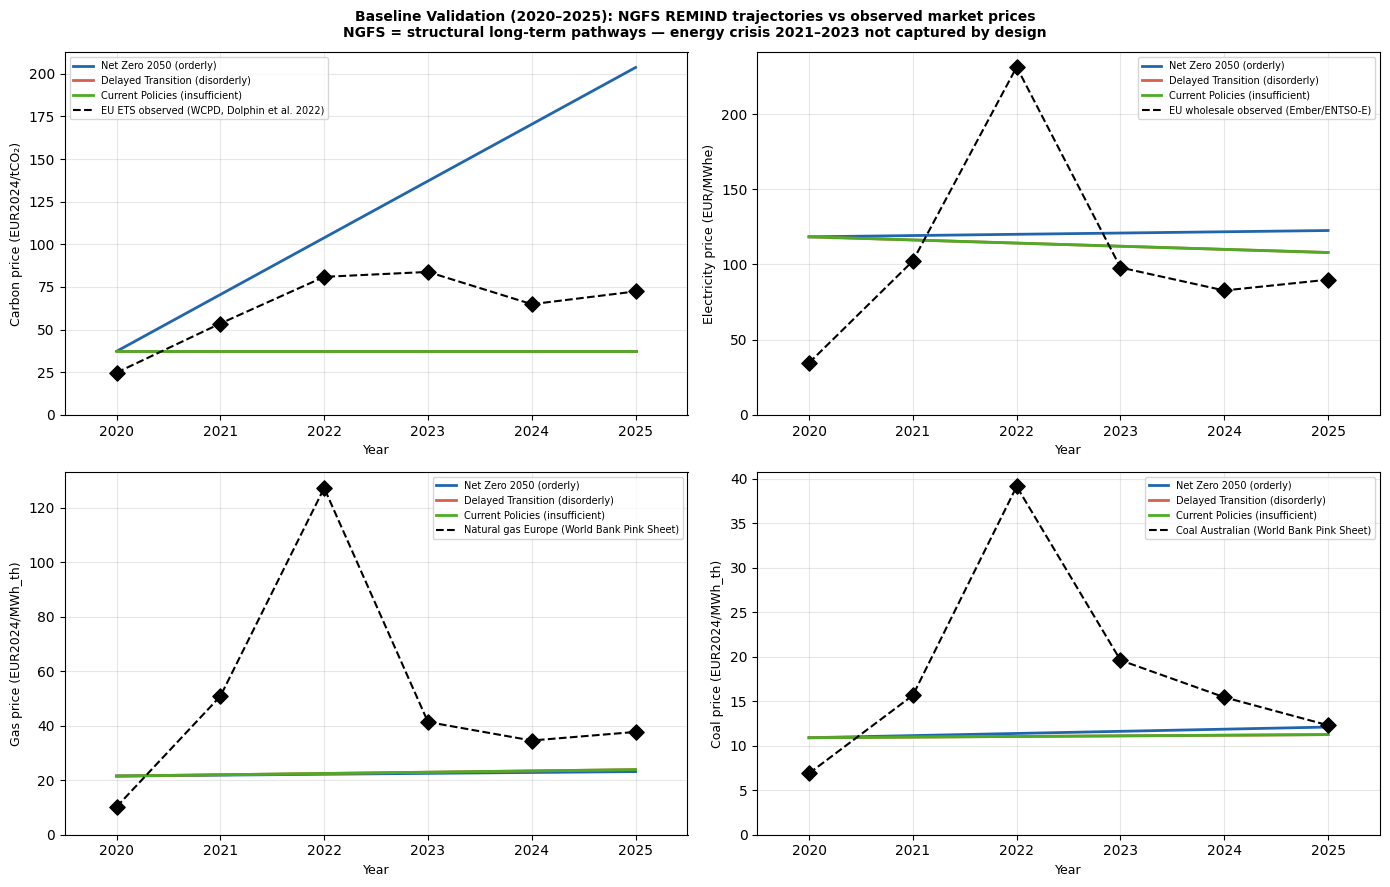

Observed vs NGFS Current Policies — key years:
  Carbon  2020: obs=24.8 vs NGFS=37.2 EUR2024/tCO2
  Carbon  2022: obs=80.9 vs NGFS=37.2 EUR2024/tCO2
  Elec    2022: obs=231.3 vs NGFS=114.2 EUR/MWhe


In [14]:
# ── Baseline Validation: NGFS vs observed 2020–2025 ──────────────────────────
# All NGFS prices already in df_annual in EUR2024/MWh (or EUR2024/tCO2 for carbon)
# Observed data conversion:
#   Carbon: already in EUR (WCPD), no conversion needed
#   Gas ($/mmbtu) → EUR2024/MWh_th: × 0.924 (USD→EUR) / 0.29307 (mmbtu→MWh)
#   Coal ($/mt)   → EUR2024/MWh_th: × 0.924 / 8.139 (1t ≈ 29.3GJ/3.6 = 8.139 MWh_th)
USD_TO_EUR2024 = 0.924  # ECB 2024 average (same as Task 2 FX used for NGFS)

YEARS_VAL = list(range(2020, 2026))

# ── Load observed data ────────────────────────────────────────────────────────
# 1. Carbon — EU ETS (WCPD, ets_id='eu_ets', already in EUR nominal ≈ EUR2024)
wcpd = pd.read_csv('../../data/raw/wcpd_co2_Germany.csv')
carbon_obs = (
    wcpd[(wcpd['ets_id'] == 'eu_ets') & (wcpd['year'].between(2020, 2025))]
    [['year','ets_price']].drop_duplicates().sort_values('year')
)

# 2. Electricity — EU average wholesale (Ember/ENTSO-E, EUR/MWhe)
EU27_ISO3 = ['AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU',
             'GRC','HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT',
             'ROU','SVK','SVN','ESP','SWE']
ember = pd.read_csv('../../data/raw/ember_wholesale_electricity_monthly.csv')
ember['year'] = pd.to_datetime(ember['Date']).dt.year
elec_obs = (
    ember[ember['ISO3 Code'].isin(EU27_ISO3) & ember['year'].between(2020, 2025)]
    .groupby('year')['Price (EUR/MWhe)'].mean().reset_index()
)

# 3. Gas and Coal — World Bank Pink Sheet (USD nominal → EUR2024/MWh_th)
wb_raw = pd.read_excel(
    '../../data/raw/worldbank_commodity_annual.xlsx',
    sheet_name='Annual Prices (Nominal)', header=None
)
header = wb_raw.iloc[6]
data   = wb_raw.iloc[8:].copy()
data.columns = header
year_col = data.columns[0]
wb_sub = data[[year_col, 'Natural gas, Europe', 'Coal, Australian']].copy()
wb_sub.columns = ['year', 'gas_usd_mmbtu', 'coal_usd_mt']
wb_sub['year'] = pd.to_numeric(wb_sub['year'], errors='coerce')
wb_sub = wb_sub[wb_sub['year'].between(2020, 2025)].dropna().sort_values('year')
wb_sub['gas_eur2024_mwh']  = wb_sub['gas_usd_mmbtu']  * USD_TO_EUR2024 / 0.29307
wb_sub['coal_eur2024_mwh'] = wb_sub['coal_usd_mt']     * USD_TO_EUR2024 / 8.139

# ── Extract NGFS trajectories for 2020–2025 ──────────────────────────────────
def ngfs_yr(variable):
    return (
        df_annual[(df_annual['variable'] == variable) &
                  (df_annual['year'].isin(YEARS_VAL))]
        .pivot_table(index='year', columns='scenario', values='value')
        .reindex(columns=SCENARIOS)
    )

ngfs_carbon = ngfs_yr('Price|Carbon')
ngfs_elec   = ngfs_yr('Price|Secondary Energy|Electricity')
ngfs_gas    = ngfs_yr('Price|Primary Energy|Gas')
ngfs_coal   = ngfs_yr('Price|Primary Energy|Coal')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

panels = [
    (axes[0,0], ngfs_carbon, carbon_obs['year'], carbon_obs['ets_price'],
     'Carbon price (EUR2024/tCO₂)',
     'EU ETS observed (WCPD, Dolphin et al. 2022)'),
    (axes[0,1], ngfs_elec,   elec_obs['year'],   elec_obs['Price (EUR/MWhe)'],
     'Electricity price (EUR/MWhe)',
     'EU wholesale observed (Ember/ENTSO-E)'),
    (axes[1,0], ngfs_gas,    wb_sub['year'],     wb_sub['gas_eur2024_mwh'],
     'Gas price (EUR2024/MWh_th)',
     'Natural gas Europe (World Bank Pink Sheet)'),
    (axes[1,1], ngfs_coal,   wb_sub['year'],     wb_sub['coal_eur2024_mwh'],
     'Coal price (EUR2024/MWh_th)',
     'Coal Australian (World Bank Pink Sheet)'),
]

for ax, ngfs_df, obs_x, obs_y, ylabel, obs_label in panels:
    for scenario in SCENARIOS:
        if scenario in ngfs_df.columns:
            ax.plot(ngfs_df.index, ngfs_df[scenario],
                    color=SCENARIO_COLORS[scenario], linewidth=2,
                    label=SCENARIO_LABELS[scenario])
    ax.scatter(obs_x, obs_y, color='black', s=60, zorder=5, marker='D')
    ax.plot(obs_x, obs_y, color='black', linewidth=1.5, linestyle='--',
            label=obs_label)
    ax.set_xlim(2019.5, 2025.5)
    ax.set_ylim(bottom=0)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle(
    'Baseline Validation (2020–2025): NGFS REMIND trajectories vs observed market prices\n'
    'NGFS = structural long-term pathways — energy crisis 2021–2023 not captured by design',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig_baseline_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observed vs NGFS Current Policies — key years:")
print(f"  Carbon  2020: obs={carbon_obs[carbon_obs['year']==2020]['ets_price'].values[0]:.1f}"
      f" vs NGFS={ngfs_carbon.loc[2020,'Current Policies']:.1f} EUR2024/tCO2")
print(f"  Carbon  2022: obs={carbon_obs[carbon_obs['year']==2022]['ets_price'].values[0]:.1f}"
      f" vs NGFS={ngfs_carbon.loc[2022,'Current Policies']:.1f} EUR2024/tCO2")
print(f"  Elec    2022: obs={elec_obs[elec_obs['year']==2022]['Price (EUR/MWhe)'].values[0]:.1f}"
      f" vs NGFS={ngfs_elec.loc[2022,'Current Policies']:.1f} EUR/MWhe")